# 代码实现

## 加载数据

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# 加载数据
X, y = load_iris(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size= 0.3, random_state=42
)

## 构建随机森林

In [2]:
from sklearn.ensemble import RandomForestClassifier
# 构建随机森林
rf = RandomForestClassifier(
  n_estimators = 100,   # 树的数量
  max_features='sqrt',  # 每次分裂时随机选取的特征数量
  oob_score=True,       # 启用 OOB 估计
  random_state=42,
  n_jobs=-1             # 并行训练
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


## 评估

In [3]:
from sklearn.metrics import accuracy_score
# 评估
print(f"OOB 准确率: {rf.oob_score_:.4f}")
print(f"测试集准确率: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

OOB 准确率: 0.9429
测试集准确率: 1.0000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载数据
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 构建随机森林
rf = RandomForestClassifier(
    n_estimators=100,     # 树的数量
    max_features='sqrt',  # 每次分裂时随机选取的特征数
    oob_score=True,       # 启用 OOB 估计
    random_state=42,
    n_jobs=-1             # 并行训练
)

rf.fit(X_train, y_train)

# 评估
print(f"OOB 准确率: {rf.oob_score_:.4f}")
print(f"测试集准确率: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

# 特征重要性

## 基于不纯度减少的重要性 MDI

In [4]:
# 基于不纯度减少的重要性
feat_names = load_iris().feature_names
importance = rf.feature_importances_


## 基于排列的重要性

In [5]:
from sklearn.inspection import permutation_importance
# 基于排列的重要性
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)


## 绘图

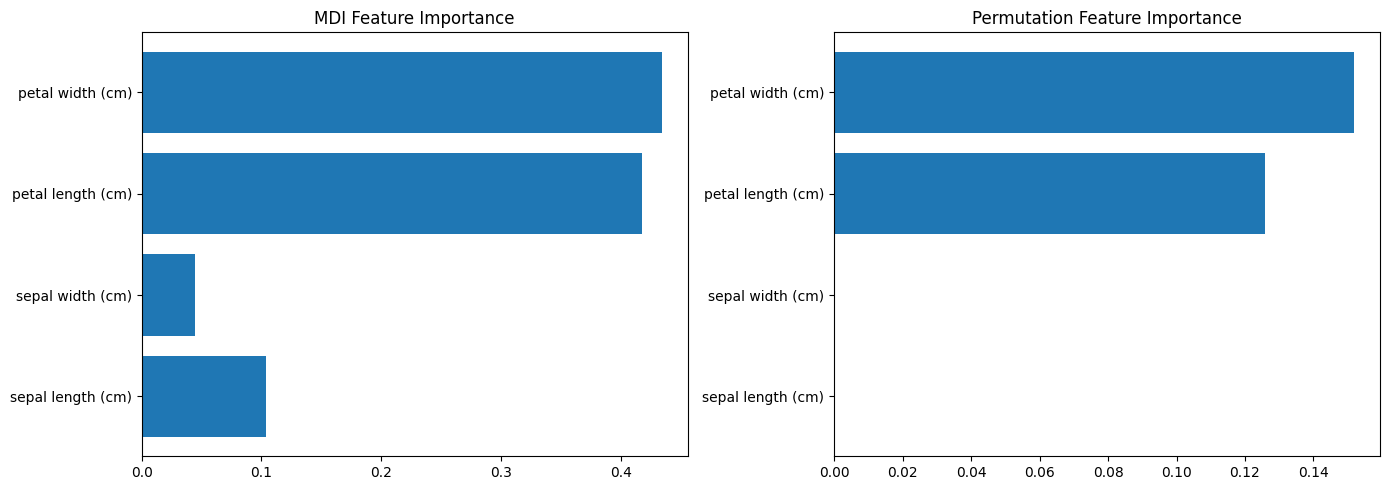

In [7]:
import matplotlib.pyplot as plt
# 绘图
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].barh(feat_names, importance)
axes[0].set_title('MDI Feature Importance')

axes[1].barh(feat_names, perm_imp.importances_mean)
axes[1].set_title('Permutation Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 基于不纯度的重要性
feat_names = load_iris().feature_names
importances = rf.feature_importances_

# 基于排列的重要性
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feat_names, importances)
axes[0].set_title('MDI Feature Importance')

axes[1].barh(feat_names, perm_imp.importances_mean)
axes[1].set_title('Permutation Feature Importance')

plt.tight_layout()
plt.show()